In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import numpy             as np 
import pandas            as pd
import yfinance          as yf
import matplotlib.pyplot as plt

In [3]:
nvda    = yf.Ticker("NVDA")

In [4]:
info = nvda.info

print("Company:", info.get("longName"))
print("Sector:", info.get("sector"))
print("Industry:", info.get("industry"))
print("Employees:", info.get("fullTimeEmployees"))
print("Description:", info.get("longBusinessSummary"))

Company: NVIDIA Corporation
Sector: Technology
Industry: Semiconductors
Employees: 42000
Description: NVIDIA Corporation operates as a data center scale AI infrastructure company. The company operates through two segments, Compute & Networking, and Graphics segments. The Compute & Networking segment provides data center accelerated computing and networking platforms and artificial intelligence solutions and software, and automotive platforms and autonomous and electric vehicle solutions, including software. The Graphics segment offers GeForce GPUs for gaming and PCs; Quadro/NVIDIA RTX GPUs for enterprise workstation graphics. The company's products are used in gaming, professional visualization, data center, and automotive markets. The company sells its products to original equipment manufacturers, original device manufacturers, system integrators and distributors, independent software vendors, cloud service providers, add-in board manufacturers, distributors, automotive manufacturers 

In [5]:
metrics = {
    "Market Cap"   :   info.get("marketCap"),
    "P/E Ratio"    :   info.get("trailingPE"),
    "Forward P/E"  :   info.get("forwardPE"),
    "PEG Ratio"    :   info.get("pegRatio"),
    "Price/Sales"  :   info.get("priceToSalesTrailing12Months"),
    "Price/Book"   :   info.get("priceToBook"),
    "EV/EBITDA"    :   info.get("enterpriseToEbitda"),
    "EPS (TTM)"    :   info.get("trailingEps"),
    "Revenue (TTM)":   info.get("totalRevenue"),
    "Profit Margin":   info.get("profitMargins"),
    "ROE"          :   info.get("returnOnEquity"),
    "Debt/Equity"  :   info.get("debtToEquity"),
}

for k, v in metrics.items():
    print(f"{k:20}: {v}")

Market Cap          : 4858083540992
P/E Ratio           : 40.70876
Forward P/E         : 17.784216
PEG Ratio           : 0.72
Price/Sales         : 22.497585
Price/Book          : 30.883808
EV/EBITDA           : 36.073
EPS (TTM)           : 4.91
Revenue (TTM)       : 215938007040
Profit Margin       : 0.55603004
ROE                 : 1.01485
Debt/Equity         : 7.255


In [6]:
hist = nvda.history(period="1y")

# Daily returns
hist["Daily Return"] = hist["Close"].pct_change()

# Cumulative return
hist["Cumulative Return"] = (1 + hist["Daily Return"]).cumprod() - 1

print(f"1-Year Return:    {hist['Cumulative Return'].iloc[-1]:.2%}")
print(f"Max Daily Gain:   {hist['Daily Return'].max():.2%}")
print(f"Max Daily Loss:   {hist['Daily Return'].min():.2%}")
print(f"Avg Daily Return: {hist['Daily Return'].mean():.4%}")
print(f"Volatility (Ann): {hist['Daily Return'].std() * (252**0.5):.2%}")

1-Year Return:    102.17%
Max Daily Gain:   7.87%
Max Daily Loss:   -5.46%
Avg Daily Return: 0.3043%
Volatility (Ann): 33.71%


In [7]:
# Note - Depth of Market and orderflow delta
# Moving Averages
hist["MA50"]  = hist["Close"].rolling(50).mean()
hist["MA200"] = hist["Close"].rolling(200).mean()

# Relative Strength Index (RSI)
delta = hist["Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
hist["RSI"] = 100 - (100 / (1 + gain / loss))

# Bollinger Bands
hist["BB_Mid"]   = hist["Close"].rolling(20).mean()
hist["BB_Upper"] = hist["BB_Mid"] + 2 * hist["Close"].rolling(20).std()
hist["BB_Lower"] = hist["BB_Mid"] - 2 * hist["Close"].rolling(20).std()

# MACD
ema12 = hist["Close"].ewm(span=12).mean()
ema26 = hist["Close"].ewm(span=26).mean()
hist["MACD"]        = ema12 - ema26
hist["MACD_Signal"] = hist["MACD"].ewm(span=9).mean()

print(hist[["Close", "MA50", "MA200", "RSI", "MACD"]].tail(5))

                                Close        MA50       MA200        RSI  \
Date                                                                       
2026-04-15 00:00:00-04:00  198.869995  182.381602  181.313370  71.383188   
2026-04-16 00:00:00-04:00  198.350006  182.741997  181.515301  83.643590   
2026-04-17 00:00:00-04:00  201.679993  183.291986  181.757328  92.807026   
2026-04-20 00:00:00-04:00  202.059998  183.895772  181.981509  98.629082   
2026-04-21 00:00:00-04:00  199.880005  184.185373  182.184342  91.256529   

                               MACD  
Date                                 
2026-04-15 00:00:00-04:00  3.135426  
2026-04-16 00:00:00-04:00  3.901882  
2026-04-17 00:00:00-04:00  4.723555  
2026-04-20 00:00:00-04:00  5.343800  
2026-04-21 00:00:00-04:00  5.594946  


/tmp/ipykernel_16/2656208101.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data  = yf.download(peers, period="1y")["Close"]
[*********************100%***********************]  3 of 3 completed


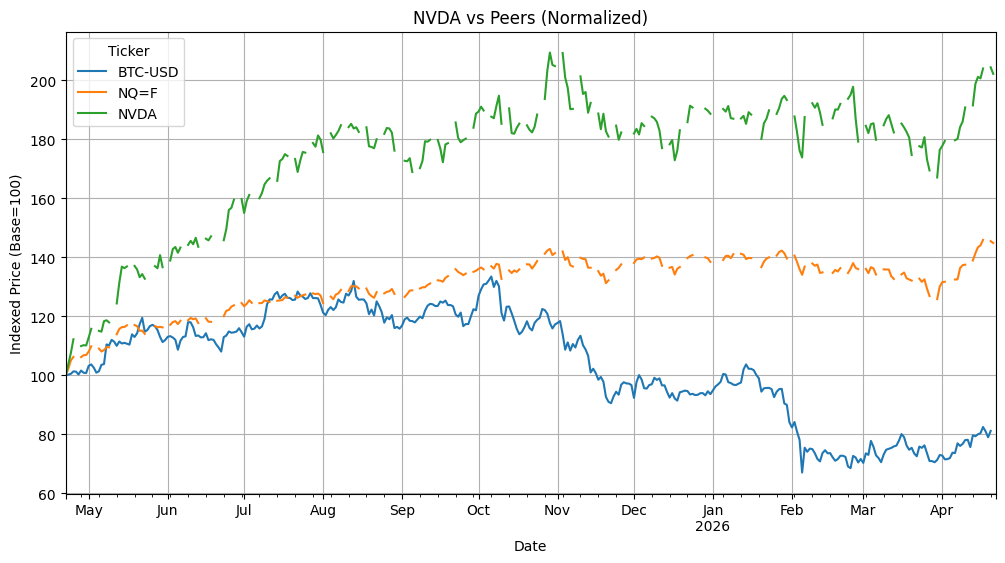

In [8]:
#  tickers = yf.Tickers("NQ=F VIX BTC-USD")
peers = ["NVDA", "NQ=F", "BTC-USD"]
data  = yf.download(peers, period="1y")["Close"]

# Normalize to 100 at start
normalized = (data / data.iloc[0]) * 100

normalized.plot(figsize=(12, 6), title="NVDA vs Peers (Normalized)")
plt.ylabel("Indexed Price (Base=100)")
plt.grid(True)
plt.show()

/tmp/ipykernel_16/3876202590.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data  = yf.download(peers, period="1y")["Close"]
[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_16/3876202590.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix   = yf.download("^VIX", period="1y")["Close"]
[*********************100%***********************]  1 of 1 completed


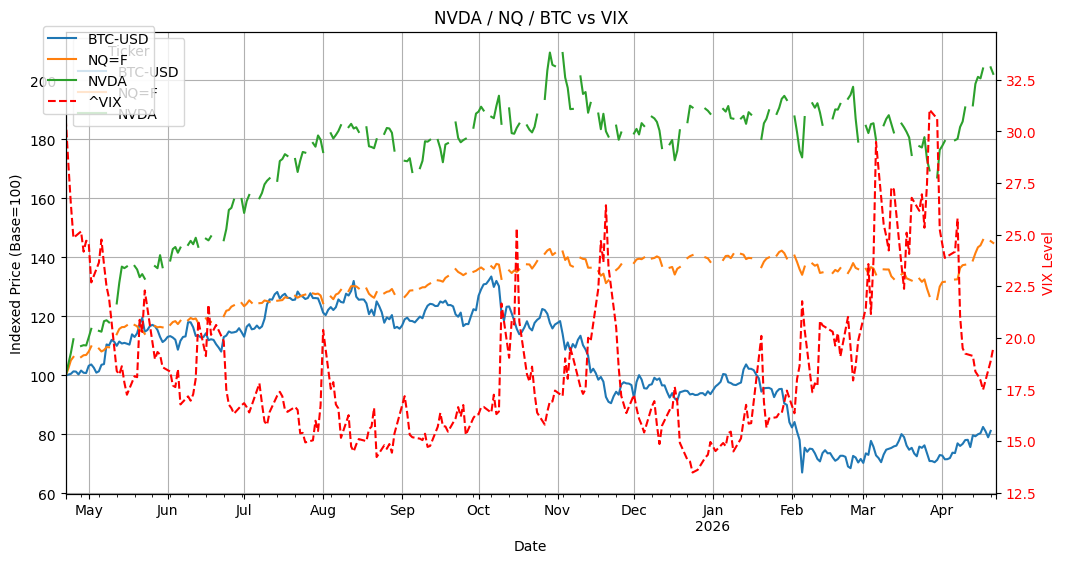

In [9]:
peers = ["NVDA", "NQ=F", "BTC-USD"]
data  = yf.download(peers, period="1y")["Close"]
vix   = yf.download("^VIX", period="1y")["Close"]

normalized = (data / data.iloc[0]) * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

normalized.plot(ax=ax1)
ax1.set_ylabel("Indexed Price (Base=100)")

ax2 = ax1.twinx()
ax2.plot(vix, color="red", linestyle="--", label="^VIX")
ax2.set_ylabel("VIX Level", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_title("NVDA / NQ / BTC vs VIX")
ax1.grid(True)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()